In [103]:
# Import libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from IPython.display import display
import os

In [104]:
# Step 1: Unzip the files
# Unzip file
file_path = "./data_v3.zip"
output_folder= Path("")
!unzip {file_path} -d {output_folder}

Archive:  /Users/gauri1399/Desktop/Northwestern/Final/data_v3.zip
 extracting: ./data_v3/antibodies.csv  
 extracting: ./data_v3/bal.csv       
 extracting: ./data_v3/demographics.csv  
 extracting: ./data_v3/lab_report.csv  
 extracting: ./data_v3/libraries.csv  
 extracting: ./data_v3/medications.csv  
 extracting: ./data_v3/mrss.csv      
 extracting: ./data_v3/pft.csv       
 extracting: ./data_v3/skin_biopsies.csv  
 extracting: ./data_v3/ssc_subtype.csv  
 extracting: ./data_v3/vitals.csv    


In [105]:
# Step 2: Store Datasets as a dictionary

# Path to folder containing CSV files
data_folder = Path("./data_v3/")

# Store datasets
datasets = {}

# Function to clean column names
def clean_columns(df):
    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[^\w]+", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df

ID_CANDIDATES = [
    "reg_id",
    "case_number",
    "study_code",
    "patient_id",
    "subject_id",
    "participant_id",
    "case_id",
    "record_id",
]

DATE_CANDIDATES = [
    "date_recorded",
    "date",
    "visit_date",
    "collection_date",
    "record_date",
    "test_date",
    "assessment_date",
    "sample_date",
    "pft_dts",
    "dts",
    "procedure_date",
    "order_date",
    "processing_date",
    "biopsy_date",
]


def find_id_col(df, extra_candidates=None):
    for c in (extra_candidates or []) + ID_CANDIDATES:
        if c in df.columns:
            return c
    raise KeyError(f"No id column found among candidates. Columns present: {list(df.columns)}")


def find_date_col(df, extra_candidates=None):
    for c in (extra_candidates or []) + DATE_CANDIDATES:
        if c in df.columns:
            return c
    raise KeyError(f"No date column found among candidates. Columns present: {list(df.columns)}")

In [106]:
#Step 3: Print a per-column data-quality summary

column_info = None

# Read and process each CSV
for file in data_folder.glob("*.csv"):

    name = file.stem

    # Read CSV
    df = pd.read_csv(file)

    # Clean columns
    df = clean_columns(df)

    # Store dataframe
    datasets[name] = df

    print("=" * 80)
    print(f"Dataset: {name}")
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}")

    # Create column summary table
    column_info = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str).values,
        "Missing Values": df.isna().sum().values,
        "Duplicate Values": [
          df[col].duplicated().sum()
          for col in df.columns
      ],
        "Duplicate (%)": [
        round((df[col].duplicated().sum() / len(df)) * 100, 2)
        for col in df.columns
    ]
  })
    display(column_info)

Dataset: medications
Rows: 3,273
Columns: 4


,Column,Data Type,Missing Values,Duplicate Values,Duplicate (%)
0,reg_id,object,0,1946,59.46
1,date,object,35,1266,38.68
2,medication,object,20,3256,99.48
3,dose,object,85,3249,99.27


Dataset: antibodies
Rows: 3,511
Columns: 4


,Column,Data Type,Missing Values,Duplicate Values,Duplicate (%)
0,case_number,object,0,2080,59.24
1,dts,object,0,1558,44.37
2,test,object,0,3508,99.91
3,value,object,0,3507,99.89


Dataset: ssc_subtype
Rows: 1,500
Columns: 7


...

,Column,Data Type,Missing Values,Duplicate Values,Duplicate (%)
0,case_number,object,0,3895,76.84
1,pft_dts,object,0,3861,76.17
2,description,object,0,5066,99.94
3,name,object,0,5066,99.94
4,ord_value,float64,794,4320,85.22


Dataset: demographics
Rows: 1,500
Columns: 12


,Column,Data Type,Missing Values,Duplicate Values,Duplicate (%)
0,study,object,0,1499,99.93
1,case_number,object,0,0,0.00
2,first_name,object,0,1157,77.13
3,last_name,object,0,1188,79.20
4,birth_date,object,0,66,4.40
5,ethnicity,object,0,1498,99.87
6,gender,object,0,1498,99.87
7,races,object,0,1496,99.73
8,diagnosis,object,0,1499,99.93
9,state,object,0,1492,99.47


Dataset: bal
Rows: 1,170
Columns: 7


,Column,Data Type,Missing Values,Duplicate Values,Duplicate (%)
0,bal_id,object,0,0,0.00
1,reg_id,object,0,350,29.91
2,procedure_date,object,0,247,21.11
3,procedure_site,object,0,1165,99.57
4,volume_instilled_ml,int64,0,1166,99.66
5,volume_recovered_ml,float64,0,696,59.49
6,bal_comment,object,372,1163,99.40


In [107]:
# # Step 4: Change to common identifier and date column names

# # Rename matching columns to common names
for name, df in datasets.items():
    rename_dict = {}

    # Rename identifier column
    for col in df.columns:
        if col.lower() in ID_CANDIDATES:
            rename_dict[col] = "reg_id"

    # Rename date column
    for col in df.columns:
        if col.lower() in DATE_CANDIDATES:
            rename_dict[col] = "date_recorded"

    # Apply renaming
    if rename_dict:
        df.rename(columns=rename_dict, inplace=True)
        print(f"{name}: {rename_dict}")

medications: {'reg_id': 'reg_id', 'date': 'date_recorded'}
antibodies: {'case_number': 'reg_id', 'dts': 'date_recorded'}
ssc_subtype: {'study_code': 'reg_id'}
mrss: {'reg_id': 'reg_id', 'date': 'date_recorded'}
lab_report: {'reg_id': 'reg_id', 'order_date': 'date_recorded'}
skin_biopsies: {'case_number': 'reg_id', 'biopsy_date': 'date_recorded'}
libraries: {'reg_id': 'reg_id', 'processing_date': 'date_recorded'}
vitals: {'reg_id': 'reg_id', 'date': 'date_recorded'}
pft: {'case_number': 'reg_id', 'pft_dts': 'date_recorded'}
demographics: {'case_number': 'reg_id'}
bal: {'reg_id': 'reg_id', 'procedure_date': 'date_recorded'}


In [108]:
# Step 5: Pivot selected long-format tables into wide format

# Retrieve tables from the datasets dictionary
pft = datasets["pft"].copy()
vitals = datasets["vitals"].copy()
lab_report = datasets["lab_report"].copy()

# ------------------------------------------------------------
# 1. Pulmonary Function Tests (PFT)

pft_id_col = find_id_col(pft)
pft_date_col = find_date_col(pft, extra_candidates=["pft_dts"])

pft_wide = (
    pft.pivot_table(
        index=["reg_id", "date_recorded"],
        columns="name",
        values="ord_value",
        aggfunc="first"
    )
    .reset_index()
)
pft_wide = clean_columns(pft_wide)

# ------------------------------------------------------------
# 2. Vitals

vitals_id_col = find_id_col(vitals)
vitals_date_col = find_date_col(vitals)

vitals_wide = (
    vitals.pivot_table(
        index=["reg_id", "date_recorded"],
        columns="vital_type_name_category",
        values="vital_value",
        aggfunc="first"
    )
    .reset_index()
)
vitals_wide = clean_columns(vitals_wide)

# ------------------------------------------------------------
# 3. Lab Reports

lab_report["value"] = pd.to_numeric(
    lab_report["value"],
    errors="coerce"
)

lab_report_wide = (
    lab_report.pivot_table(
        index=["reg_id", "date_recorded"],
        columns="component_name",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)
lab_report_wide = clean_columns(lab_report_wide)

In [109]:
lab_report_wide

component_name,reg_id,date_recorded,absolute_basophils,absolute_eosinophils,absolute_lymphocytes,absolute_monocyte,basophils,eosinophils,hematocrit,hemoglobin,...,mch,mchc,mcv,monocytes_body_fluid,neutrophils,nm_bkr_absolute_neutrophil,platelet_count,rbc,rdw,wbc
0,subject_2005,2024-01-06,NaN,0.16,0.75,0.48,NaN,NaN,NaN,12.8,...,NaN,NaN,82.3,NaN,NaN,NaN,241.0,NaN,15.6,5.8
1,subject_2005,2024-04-29,NaN,NaN,2.15,0.54,NaN,NaN,42.1,13.8,...,NaN,NaN,NaN,NaN,54.2,4.14,330.0,NaN,16.3,7.6
2,subject_2005,2024-08-23,NaN,NaN,1.13,NaN,NaN,NaN,31.8,10.7,...,NaN,NaN,NaN,NaN,NaN,NaN,278.0,NaN,NaN,6.3
3,subject_2005,2024-08-31,NaN,0.00,1.72,NaN,NaN,NaN,35.0,11.9,...,NaN,NaN,94.0,NaN,67.3,6.33,298.0,NaN,16.0,9.4
4,subject_2009,2020-07-27,NaN,NaN,1.56,0.37,NaN,3.0,NaN,NaN,...,29.0,31.9,95.2,NaN,NaN,3.21,NaN,NaN,NaN,5.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3259,subject_8977,2021-01-05,0.02,0.00,1.46,0.88,0.4,NaN,NaN,11.6,...,27.8,33.8,91.2,NaN,NaN,NaN,375.0,NaN,NaN,9.8
3260,subject_8977,2021-10-12,NaN,NaN,2.22,NaN,0.9,NaN,NaN,12.7,...,32.5,32.5,85.9,NaN,NaN,NaN,375.0,NaN,NaN,7.4
3261,subject_8985,2018-10-30,NaN,0.28,2.48,0.75,1.1,NaN,37.4,13.1,...,NaN,NaN,NaN,9.9,49.9,NaN,331.0,NaN,14.5,7.6
3262,subject_8989,2020-03-06,NaN,0.10,0.98,0.34,0.9,1.9,43.1,14.4,...,28.9,NaN,94.0,NaN,NaN,3.82,294.0,5.84,16.0,NaN


In [110]:
# Step 6: Fix mixed units in demographics height

demographics = datasets["demographics"]
demographics["height_was_cm"] = demographics["height"].apply(lambda h: bool(pd.notna(h) and h >= 100))
demographics["height"] = demographics["height"].apply(
    lambda h: round(h / 2.54, 1) if pd.notna(h) and h >= 100 else h
)
print(f"Converted {int(demographics['height_was_cm'].sum())} height values from cm to inches.")
print(f"New height range: {demographics['height'].min()} - {demographics['height'].max()}")

Converted 265 height values from cm to inches.
New height range: 54.7 - 78.5


In [111]:
# Step 6: Summary of pivoted tables
from IPython.display import display, Markdown

pivoted_tables = {
    "PFT": pft_wide,
    "Vitals": vitals_wide,
    "Lab Reports": lab_report_wide
}
for name, df in pivoted_tables.items():

    print("=" * 80)
    print(f"{name} Dataset")
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}")

    # Create quality summary table
    summary = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str).values,
        "Missing Values": df.isna().sum().values,
        "Missing (%)": (
            (df.isna().mean() * 100)
            .round(2)
            .values
        ),
        "Duplicate Values": [
            df[col].duplicated().sum()
            for col in df.columns
        ],
        "Duplicate (%)": [
            round(
                (df[col].duplicated().sum() / len(df)) * 100,
                2
            )
            for col in df.columns
        ]
    })

    display(summary.style.hide(axis="index"))

PFT Dataset
Rows: 1,723
Columns: 5


Column,Data Type,Missing Values,Missing (%),Duplicate Values,Duplicate (%)
reg_id,object,0,0.000000,549,31.860000
date_recorded,object,0,0.000000,515,29.890000
dlco_sb,float64,894,51.890000,1295,75.160000
fev1,float64,0,0.000000,1132,65.700000
fvc,float64,0,0.000000,1113,64.600000


Vitals Dataset
Rows: 9,131
Columns: 7


Column,Data Type,Missing Values,Missing (%),Duplicate Values,Duplicate (%)
reg_id,object,0,0.000000,7628,83.540000
date_recorded,object,0,0.000000,6084,66.630000
bmi,float64,1354,14.830000,8833,96.740000
bp_diastolic,float64,1283,14.050000,9085,99.500000
bp_systolic,float64,1283,14.050000,9065,99.280000
pulse,float64,750,8.210000,9071,99.340000
weight_in_pound,float64,735,8.050000,8000,87.610000


Lab Reports Dataset
Rows: 3,264
Columns: 21


Column,Data Type,Missing Values,Missing (%),Duplicate Values,Duplicate (%)
reg_id,object,0,0.000000,1951,59.770000
date_recorded,object,0,0.000000,1247,38.200000
absolute_basophils,float64,1907,58.430000,3248,99.510000
absolute_eosinophils,float64,1873,57.380000,3201,98.070000
absolute_lymphocytes,float64,1942,59.500000,2949,90.350000
absolute_monocyte,float64,1865,57.140000,3152,96.570000
basophils,float64,1902,58.270000,3246,99.450000
eosinophils,float64,1898,58.150000,3197,97.950000
hematocrit,float64,1350,41.360000,3029,92.800000
hemoglobin,float64,1349,41.330000,3182,97.490000


In [112]:
# Step 7: Generate Relationship Summary Table

relationships = []

tables = list(datasets.keys())

for i in range(len(tables)):
    for j in range(i + 1, len(tables)):

        table1 = tables[i]
        table2 = tables[j]

        df1 = datasets[table1]
        df2 = datasets[table2]

        # Find common columns
        common_cols = set(df1.columns).intersection(df2.columns)

        for col in common_cols:

            # Focus on identifier columns
            if (
                "id" in col.lower()
                or "case" in col.lower()
                or "number" in col.lower()
            ):

                # Determine relationship type
                table1_unique = df1[col].is_unique
                table2_unique = df2[col].is_unique

                if table1_unique and table2_unique:
                    relationship = "One-to-One"

                elif table1_unique and not table2_unique:
                    relationship = "One-to-Many"

                elif not table1_unique and table2_unique:
                    relationship = "One-to-Many"

                else:
                    relationship = "Many-to-Many"

                relationships.append({
                    "Table 1": table1,
                    "Table 2": table2,
                    "Relationship Key": col,
                    "Relationship Type": relationship
                })

# Print relatiosnhip summary
# Create summary dataframe
relationship_summary = pd.DataFrame(relationships)

# Remove duplicate relationships if any
relationship_summary = relationship_summary.drop_duplicates()

display(relationship_summary)

,Table 1,Table 2,Relationship Key,Relationship Type
0,medications,antibodies,reg_id,Many-to-Many
1,medications,ssc_subtype,reg_id,One-to-Many
2,medications,mrss,reg_id,Many-to-Many
3,medications,lab_report,reg_id,Many-to-Many
4,medications,skin_biopsies,reg_id,Many-to-Many
5,medications,libraries,reg_id,Many-to-Many
6,medications,vitals,reg_id,Many-to-Many
7,medications,pft,reg_id,Many-to-Many
8,medications,demographics,reg_id,One-to-Many
9,medications,bal,reg_id,Many-to-Many


In [113]:
!ls {output_folder}

Data_QC.ipynb data_v3       data_v3.zip


In [114]:
# Step 8: Export cleaned datasets
output_folder.mkdir(exist_ok=True)

folder = "cleaned_datasets"
full_path = os.path.join(output_folder, folder)

os.mkdir(full_path)

# Save original datasets
for name, df in datasets.items():
    print(name)
    df.to_csv(f"{full_path}/{name}.csv", index=False)

# Save pivoted datasets
pft_wide.to_csv(f"{full_path}/pft_wide.csv", index=False)
vitals_wide.to_csv(f"{full_path}/vitals_wide.csv", index=False)
lab_report_wide.to_csv(f"{full_path}/lab_report_wide.csv", index=False)

print("All datasets saved successfully.")


medications
antibodies
ssc_subtype
mrss
lab_report
skin_biopsies
libraries
vitals
pft
demographics
bal
All datasets saved successfully.


In [115]:
# Step 9: Store new cleaned dataset
# Path to cleaned dataset folder
# cleaned_folder = Path("/Users/gauri1399/Desktop/Northwestern/Final/cleaned_datasets")



# Dictionary to store cleaned datasets


cleaned_datasets = {}

# Load all CSV files
for file in Path(full_path).glob("*.csv"):
    print(file)

    df = pd.read_csv(file)

    # Store using filename (without .csv) as key
    cleaned_datasets[file.stem] = df

print("Loaded datasets:")
print(cleaned_datasets.keys())

cleaned_datasets/medications.csv
cleaned_datasets/antibodies.csv
cleaned_datasets/ssc_subtype.csv
cleaned_datasets/mrss.csv
cleaned_datasets/vitals_wide.csv
cleaned_datasets/lab_report.csv
cleaned_datasets/pft_wide.csv
cleaned_datasets/skin_biopsies.csv
cleaned_datasets/libraries.csv
cleaned_datasets/lab_report_wide.csv
cleaned_datasets/vitals.csv
cleaned_datasets/pft.csv
cleaned_datasets/demographics.csv
cleaned_datasets/bal.csv
Loaded datasets:
dict_keys(['medications', 'antibodies', 'ssc_subtype', 'mrss', 'vitals_wide', 'lab_report', 'pft_wide', 'skin_biopsies', 'libraries', 'lab_report_wide', 'vitals', 'pft', 'demographics', 'bal'])


In [117]:
# Step 10: Assign cleaned datasets to individual dataframes
demographics = cleaned_datasets["demographics"]
antibodies = cleaned_datasets["antibodies"]
mrss = cleaned_datasets["mrss"]
bal = cleaned_datasets["bal"]
medications = cleaned_datasets["medications"]

pft_wide = cleaned_datasets["pft_wide"]
vitals_wide = cleaned_datasets["vitals_wide"]
lab_report_wide = cleaned_datasets["lab_report_wide"]

ssc_subtype = cleaned_datasets["ssc_subtype"]
skin_biopsies = cleaned_datasets["skin_biopsies"]
libraries = cleaned_datasets["libraries"]

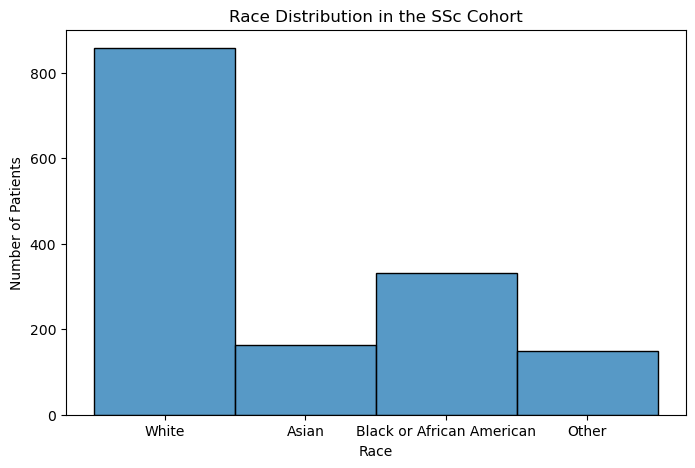

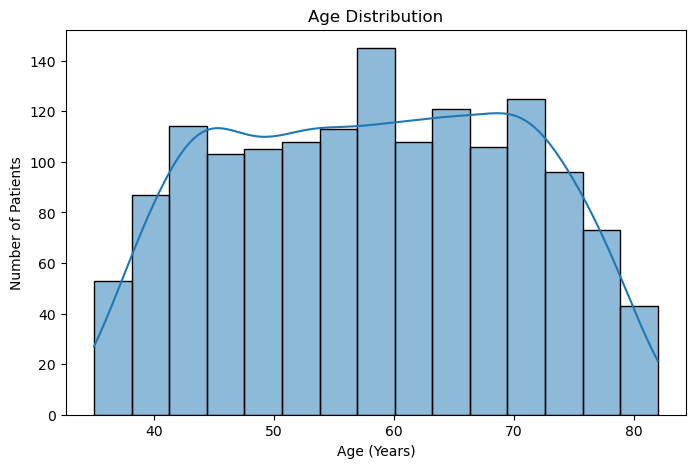

/var/folders/5l/m44zbc8s1zj27rpr7mstfkqh0000gn/T/ipykernel_97538/2944475915.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


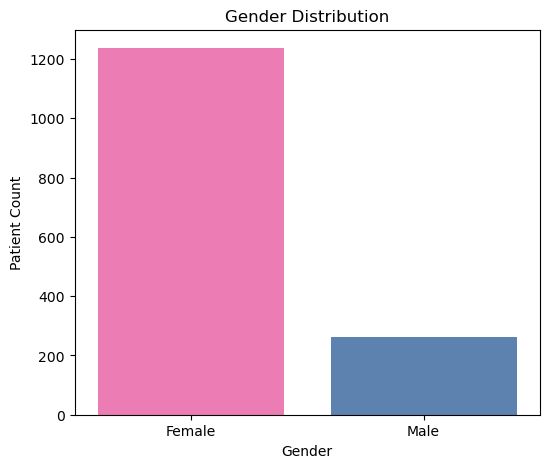

In [118]:
# Step 3: Plot graphs
# 1. Demographics

# Plot 1: Race Distribution
plt.figure(figsize=(8,5))
sns.histplot(demographics["races"], bins=20, kde=False)
plt.title("Race Distribution in the SSc Cohort")
plt.xlabel("Race")
plt.ylabel("Number of Patients")
plt.show()

#========================================================================

# Plot 2: Age distribution
demographics = cleaned_datasets["demographics"].copy()

# Convert birth date
demographics["birth_date"] = pd.to_datetime(
    demographics["birth_date"],
    errors="coerce"
)

# Calculate age
today = pd.Timestamp.today()
demographics["age"] = (
    (today - demographics["birth_date"]).dt.days / 365.25
).astype(int)

plt.figure(figsize=(8,5))

sns.histplot(
    demographics["age"],
    bins=15,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Patients")

plt.show()

#========================================================================

# Plot 3: Gender distribution
plt.figure(figsize=(6,5))
sns.countplot(
    data=demographics,
    x="gender",
    palette={
    "Female": "#FF69B4",  # Pink
    "Male": "#4F81BD"     # Blue
}
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Patient Count")

plt.show()


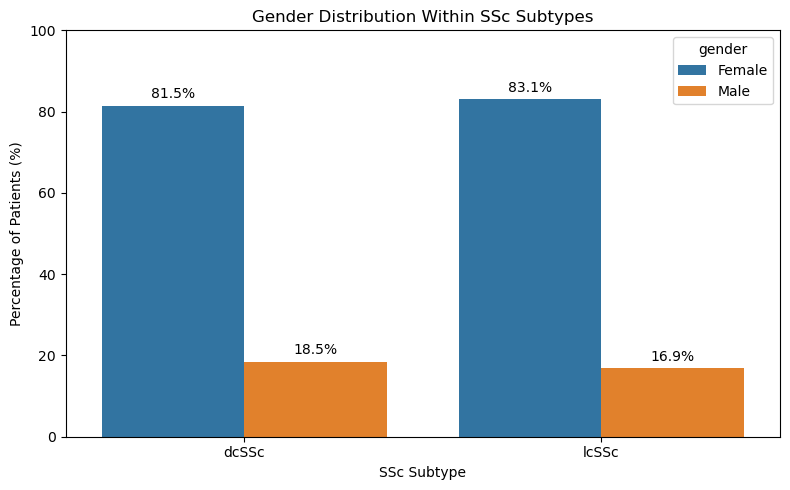

In [119]:
# 2. Merge demographics with SSc subtype information
ssc_demo = demographics.merge(
    ssc_subtype,
    on="reg_id",
    how="left"
)

# Create gender count table
ssc_gender_pct = (
    ssc_demo
    .groupby(["ssc_subtype", "gender"])
    .size()
    .reset_index(name="count")
)

# Calculate percentage within each SSc subtype
ssc_gender_pct["percentage"] = (
    ssc_gender_pct.groupby("ssc_subtype")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

# Plot 4
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=ssc_gender_pct,
    x="ssc_subtype",
    y="percentage",
    hue="gender"
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.title("Gender Distribution Within SSc Subtypes")
plt.xlabel("SSc Subtype")
plt.ylabel("Percentage of Patients (%)")

plt.ylim(0, 100)
plt.tight_layout()

plt.show()

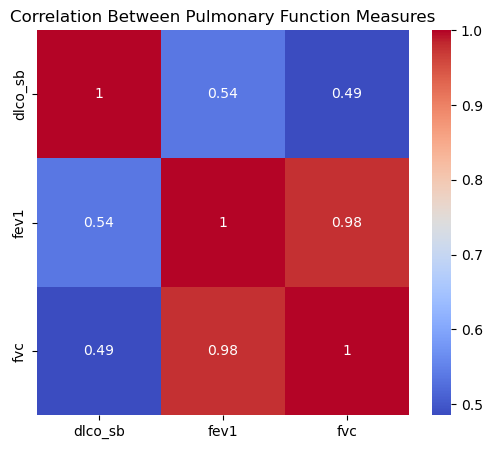

In [120]:
# 3. Correlation between PF measures

# Plot 5
plt.figure(figsize=(6,5))

corr = pft_wide[
    ["dlco_sb", "fev1", "fvc"]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Pulmonary Function Measures")

plt.show()